# Objective  :
 Implement and calculate Precision, Recall, and F1-score for a multi-class classification problem.

## Dataset : 
>The CIFAR-10 dataset. It's a perfect "clinical" dataset because it's clean, well-understood, and most importantly, perfectly balanced. With a balanced dataset, we can focus solely on the correct implementation of our metrics without the data itself skewing our results.

In [11]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Using a professional style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.2)

# Load the training data
transform = transforms.Compose([
    transforms.ToTensor()
])
train_set = torchvision.datasets.CIFAR10(root='./data',
                                         train=True,
                                         download=True,
                                         transform=transform)

test_set = torchvision.datasets.CIFAR10(root='./data',
                                         train=False,
                                         download=True,
                                         transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Number of training images: {len(train_set)}")
print(f"Number of testing images: {len(test_set)}")
print(f"Image shape: {train_set[0][0].shape}")
print(f"Number of classes: {len(classes)}")

Files already downloaded and verified
Files already downloaded and verified
Number of training images: 50000
Number of testing images: 10000
Image shape: torch.Size([3, 32, 32])
Number of classes: 10


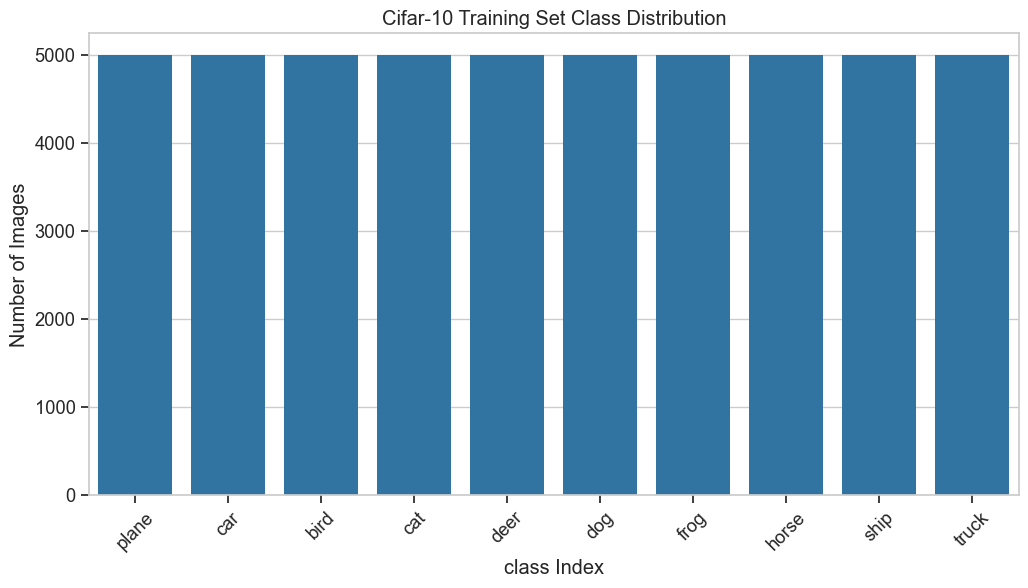

Class counts
-plane: 5000 images
-car: 5000 images
-bird: 5000 images
-cat: 5000 images
-deer: 5000 images
-dog: 5000 images
-frog: 5000 images
-horse: 5000 images
-ship: 5000 images
-truck: 5000 images


In [12]:
train_labels = [label for _, label in train_set]
class_counts = Counter(train_labels)

plt.figure(figsize=(12,6))
sns.barplot(x = list(class_counts.keys()),
            y = list(class_counts.values()))
plt.title('Cifar-10 Training Set Class Distribution')
plt.xlabel('class Index')
plt.ylabel('Number of Images')
plt.xticks(
           labels=classes,
           ticks = range(len(classes)),
           rotation = 45)
plt.show()

print("Class counts")
for i in range(len(classes)):
    print(f"-{classes[i]}: {class_counts[i]} images")

Labels:  truck horse car   deer  plane plane car   ship 


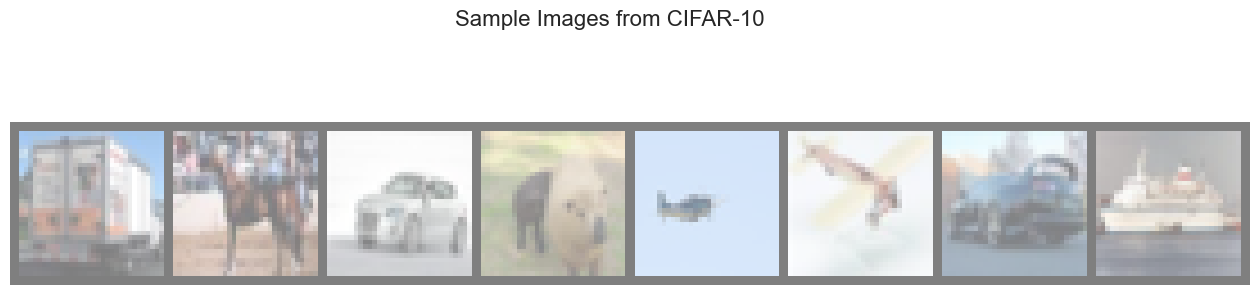

In [13]:
def imshow(img):
    img   = img / 2 + 0.5 # Unnormalize if normalization was applied
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get some random training images
dataiter = iter(torch.utils.data.DataLoader(train_set,
                                            batch_size=8,
                                            shuffle=True))
images, labels = next(dataiter)

# show images
plt.figure(figsize=(16, 4))
plt.suptitle('Sample Images from CIFAR-10', fontsize=16)
imshow(torchvision.utils.make_grid(images))
print('Labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))
plt.show()


# Implementation

### Training a Sipmple CNN

> Let's build a standard workflow. Using a Simple CNN and a professional Training Loop.



In [14]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
from torch.utils.data import DataLoader 

# GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device : {device}")


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2d = nn.Conv2d(16, 32, 3, padding= 1)
        self.fc1 = nn.Linear(32*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # print(f"Input : {x.shape}")
        x = self.conv1(x)
        # print(f"shape after first convolution : {x.shape}")
        x = F.relu(x)
        # print(f"shape after first RELU : {x.shape}")
        x = self.pool(x)
        # print(f"shape after first Pooling : {x.shape}")
        x = self.conv2d(x)
        # print(f"shape after Second Convolution : {x.shape}")
        x = F.relu(x)
        # print(f"shape after Second RELU : {x.shape}")
        x = self.pool(x)
        # print(f"shape after Second Pooling : {x.shape}")
        x = torch.flatten(x, 1)
        # print(f"shape after Flattening : {x.shape}")
        x = self.fc1(x)
        # print(f"shape after first Fully connected : {x.shape}")
        x = F.relu(x)
        # print(f"shape after Third RELU : {x.shape}")
        x = self.fc2(x)
        # print(f"shape after Second Fully connected : {x.shape}")
        return x
    




train_loader = DataLoader(train_set,
                          batch_size=64,
                          shuffle = True,
                          num_workers=3)

test_loader = DataLoader(test_set,
                          batch_size=64,
                          shuffle = False,
                          num_workers=3)


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    loss = 0.0
    progress_bar = tqdm(train_loader, desc= f"Epoch {epoch + 1} / {num_epochs}")
    for i, data in enumerate(progress_bar):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss += loss.item()
        progress_bar.set_postfix(loss=loss / (i + 1))

print("finished Training")



Using device : cuda


Epoch 5 / 5: 100%|██████████| 782/782 [01:28<00:00,  8.88it/s, loss=tensor(0.0022, device='cuda:0', grad_fn=<DivBackward0>)] 

finished Training


### Evaluating with advanced metrics


**One Important Thing to note for when using `torchmetrics`**:


**For a Multi-Class Classification**
* Initialize metrics from torchmetrics
* 'task="multiclass"' is crucial!
* 'num_classes' ensures the metric tensors are the correct shape.
* 'average="macro"' calculates the metric for each class and then * takes the average.


In [16]:
import torchmetrics
from torchmetrics import (
    Accuracy,
    Precision,
    Recall,
    F1Score
)

# Set model to evaluation modoe

model.eval()

acc_metric = Accuracy(task= 'multiclass',
                      num_classes = 10).to(device)
precision_metric = Precision(task='multiclass',
                             num_classes=10,
                             average='macro').to(device)
recall_metric = Recall(task='multiclass',
                       num_classes=10,
                       average='macro').to(device)
f1_metric = F1Score(task='multiclass',
                    num_classes=10,
                    average='macro').to(device)

with torch.no_grad():
    for data in tqdm(test_loader, desc= "Evaluating"):
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # Update the state of each metric
        acc_metric.update(preds, labels)
        precision_metric.update(preds, labels)
        recall_metric.update(preds, labels)
        f1_metric.update(preds, labels)

# Compute the final metrics
# The .compute() method aggregates the results from all batches

accuracy = acc_metric.compute()
precision = precision_metric.compute()
recall = recall_metric.compute()
f1_score = f1_metric.compute()


print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1_score:.4f}")


# It's also good practice to reset the metrics after use
acc_metric.reset()
precision_metric.reset()
recall_metric.reset()
f1_metric.reset()

c:\Users\hp\anaconda3\envs\basic\lib\site-packages\torchmetrics\utilities\imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Evaluating: 100%|██████████| 157/157 [00:29<00:00,  5.27it/s]


Overall Accuracy: 0.6636
Macro Precision: 0.6709
Macro Recall: 0.6636
Macro F1-Score: 0.6604
